# Milestone 3 — Rossmann Store Sales Forecasting
### ML models (Linear Regression, Random Forest, XGBoost) vs. classical time series (ARIMA)



## 1. Setup

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DARK_BG, PANEL_BG, GRID_CLR, TEXT_CLR = "#0e1117", "#161a23", "#2a2f3a", "#e8e8e8"
ACCENT = ["#00d4ff", "#ff2e63", "#08d9d6", "#f8b400", "#7b2ff7"]
plt.rcParams.update({
    "figure.facecolor": DARK_BG, "axes.facecolor": PANEL_BG, "axes.edgecolor": GRID_CLR,
    "axes.labelcolor": TEXT_CLR, "text.color": TEXT_CLR, "xtick.color": TEXT_CLR,
    "ytick.color": TEXT_CLR, "grid.color": GRID_CLR, "grid.alpha": 0.4, "axes.grid": True,
    "font.size": 11, "savefig.facecolor": DARK_BG, "legend.facecolor": PANEL_BG, "legend.edgecolor": GRID_CLR,
})
def style_spines(ax):
    for spine in ax.spines.values():
        spine.set_color(GRID_CLR)

def darkify_fig(fig=None):
    """Force any figure (incl. third-party plots like SHAP) into the dark theme."""
    fig = fig or plt.gcf()
    fig.patch.set_facecolor(DARK_BG)
    for ax in fig.axes:
        ax.set_facecolor(PANEL_BG)
        ax.tick_params(colors=TEXT_CLR, labelcolor=TEXT_CLR)
        for spine in ax.spines.values():
            spine.set_color(GRID_CLR)
        ax.xaxis.label.set_color(TEXT_CLR)
        ax.yaxis.label.set_color(TEXT_CLR)
        ax.title.set_color(TEXT_CLR)
        for txt in ax.texts:
            txt.set_color(TEXT_CLR)
        legend = ax.get_legend()
        if legend is not None:
            legend.get_frame().set_facecolor(PANEL_BG)
            legend.get_frame().set_edgecolor(GRID_CLR)
            for text in legend.get_texts():
                text.set_color(TEXT_CLR)

def get_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1, None))) * 100
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2, "MAPE": mape}

print("Setup complete.")

Setup complete.


## 2. Load Milestone 2 data

In [ ]:
DATA_PATH = "cleaned_final_rossmann_data_m2.zip"
df = pd.read_csv(DATA_PATH, compression="zip")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Date", "Store"]).reset_index(drop=True)

print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range: {df['Date'].min().date()} -> {df['Date'].max().date()}")
print(f"Stores: {df['Store'].nunique()}")

Dataset shape: 844,392 rows x 50 columns
Date range: 2013-01-01 -> 2015-07-31
Stores: 1115


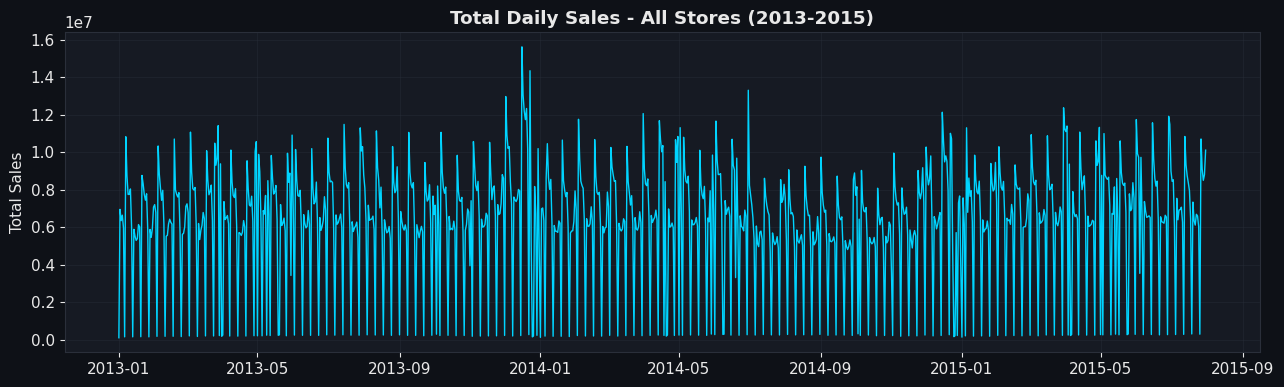

In [ ]:
daily_total = df.groupby("Date")["Sales"].sum()
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(daily_total.index, daily_total.values, color=ACCENT[0], linewidth=1)
ax.set_title("Total Daily Sales - All Stores (sanity check)", fontweight="bold")
ax.set_ylabel("Total Sales")
style_spines(ax)
plt.tight_layout()
plt.show()

## 3. Feature list

`Customers` is deliberately excluded: it isn't known ahead of time at prediction time, even though it correlates strongly with `Sales`.


In [ ]:
feature_cols = [
    "Promo", "Promo2Active", "StateHoliday", "SchoolHoliday",
    "CompetitionDistance", "CompetitionOpen",
    "DayOfWeek_2", "DayOfWeek_3", "DayOfWeek_4", "DayOfWeek_5", "DayOfWeek_6", "DayOfWeek_7",
    "Month", "Quarter", "Month_sin", "Month_cos", "DOW_sin", "DOW_cos", "IsWeekend",
    "StoreType_b", "StoreType_c", "StoreType_d", "Assortment_b", "Assortment_c",
    "Sales_Lag_7", "Sales_Lag_14", "Sales_Lag_30",
    "Sales_RollingMean_7", "Sales_RollingMean_30", "Sales_RollingStd_7",
    "Store_Month_AvgSales",
]
missing = [c for c in feature_cols if c not in df.columns]
if missing:
    print("WARNING - missing columns:", missing)
feature_cols = [c for c in feature_cols if c in df.columns]

X = df[feature_cols]
y = df["Sales"]
print(f"Using {len(feature_cols)} features.")

Using 31 features.


## 4. Chronological (time-based) train/test split

Cutoff date: 2015-02-28
Training rows: 703,660 | Test rows: 140,732


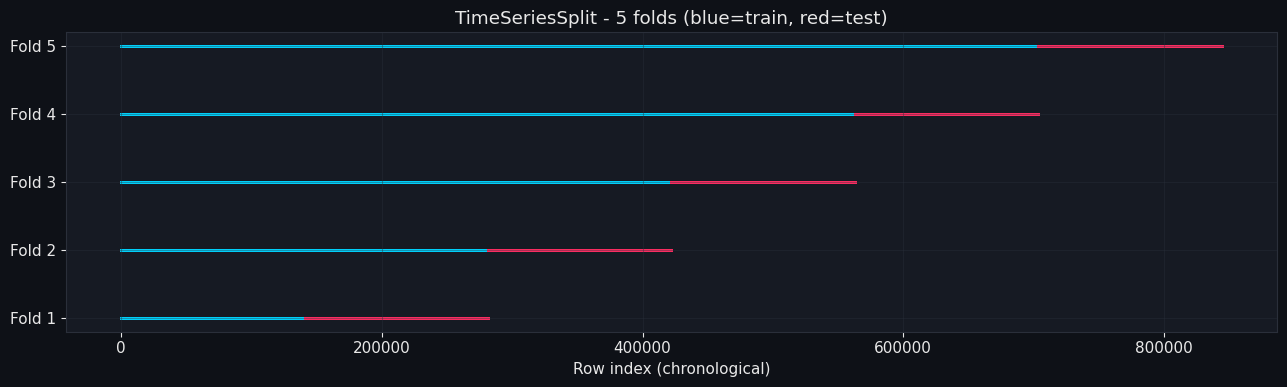

In [ ]:
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
splits = list(tscv.split(X))

fig, ax = plt.subplots(figsize=(13, 4))
for i, (tr, te) in enumerate(splits):
    ax.scatter(tr, [i] * len(tr), s=1, color=ACCENT[0])
    ax.scatter(te, [i] * len(te), s=1, color=ACCENT[1])
ax.set_yticks(range(N_SPLITS)); ax.set_yticklabels([f"Fold {i+1}" for i in range(N_SPLITS)])
ax.set_xlabel("Row index (chronological)")
ax.set_title("TimeSeriesSplit - 5 folds (blue=train, red=test)")
style_spines(ax)
plt.tight_layout()
plt.show()

train_index, test_index = splits[-1]
cutoff_date = df.iloc[test_index[0]]["Date"]
print(f"Cutoff date: {cutoff_date.date()}")
print(f"Training rows: {len(train_index):,} | Test rows: {len(test_index):,}")

## 5. `Store_Month_AvgSales` — training-only computation

This feature averages sales by (Store, Month). To avoid leaking test-period sales into it, it's computed using **training rows only**, falling back to the store's overall training mean, then the global training mean, for any store/month not seen in training.


In [ ]:
train_df = df.iloc[train_index]
train_month_avg = train_df.groupby(["Store", "Month"])["Sales"].mean()
store_overall_avg = train_df.groupby("Store")["Sales"].mean()
global_avg = train_df["Sales"].mean()

if "Store_Month_AvgSales" in feature_cols:
    old_col = df["Store_Month_AvgSales"].copy()
    map_df = train_month_avg.reset_index().rename(columns={"Sales": "SMA_fixed"})
    df = df.merge(map_df, on=["Store", "Month"], how="left")
    missing_mask = df["SMA_fixed"].isna()
    if missing_mask.any():
        df.loc[missing_mask, "SMA_fixed"] = df.loc[missing_mask, "Store"].map(store_overall_avg.to_dict())
        df["SMA_fixed"] = df["SMA_fixed"].fillna(global_avg)
    changed_pct = (df["SMA_fixed"] != old_col).mean() * 100
    print(f"Store_Month_AvgSales leakage fix applied: {changed_pct:.1f}% of rows changed value "
          f"after recomputing with train-only statistics.")
    df["Store_Month_AvgSales"] = df["SMA_fixed"]
    df = df.drop(columns=["SMA_fixed"])

X = df[feature_cols]
y = df["Sales"]
X_train, X_test = X.iloc[train_index], X.iloc[test_index]
y_train, y_test = y.iloc[train_index].values, y.iloc[test_index].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling complete. X_train_scaled:", X_train_scaled.shape, "| X_test_scaled:", X_test_scaled.shape)

Store_Month_AvgSales leakage fix applied: 100.0% of rows changed value after recomputing with train-only statistics.


Scaling complete. X_train_scaled: (703660, 31) | X_test_scaled: (140732, 31)


## 6. Train/Test diagnostic helper


In [ ]:
def plot_train_vs_test(model_name, train_metrics, test_metrics):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    metric_specs = [("R2", "R2 Score (%)", 100), ("RMSE", "RMSE", 1), ("MAE", "MAE", 1)]
    for ax, (key, label, mult) in zip(axes, metric_specs):
        vals = [train_metrics[key] * mult, test_metrics[key] * mult]
        bars = ax.bar(["Train", "Test"], vals, color=[ACCENT[0], ACCENT[1]])
        ax.set_title(label, fontsize=12, pad=8)
        style_spines(ax)
        for bar in bars:
            h = bar.get_height()
            ax.annotate(f"{h:,.1f}", xy=(bar.get_x() + bar.get_width() / 2, h), xytext=(0, 4),
                        textcoords="offset points", ha="center", color=TEXT_CLR, fontsize=9)
    fig.suptitle(f"{model_name} - Train vs. Test Performance", fontsize=14, y=1.05, fontweight="bold")
    plt.tight_layout()
    plt.show()

    gap = train_metrics["R2"] - test_metrics["R2"]
    if gap > 0.15:
        verdict = "sizeable train/test gap -> likely OVERFITTING."
    elif gap > 0.05:
        verdict = "moderate gap -> mild overfitting, worth watching."
    elif train_metrics["R2"] < 0.5 and test_metrics["R2"] < 0.5:
        verdict = "both scores low -> likely UNDERFITTING."
    else:
        verdict = "train and test scores are close -> generalizing well."
    print(f"{model_name}: Train R2={train_metrics['R2']:.3f} | Test R2={test_metrics['R2']:.3f} "
          f"| Gap={gap:.3f} -> {verdict}")

results, predictions = {}, {}
train_results, train_predictions = {}, {}

## 7. Baseline model: Linear Regression

Linear Regression: Train R2=0.823 | Test R2=0.823 | Gap=0.001 -> train and test scores are close -> generalizing well.


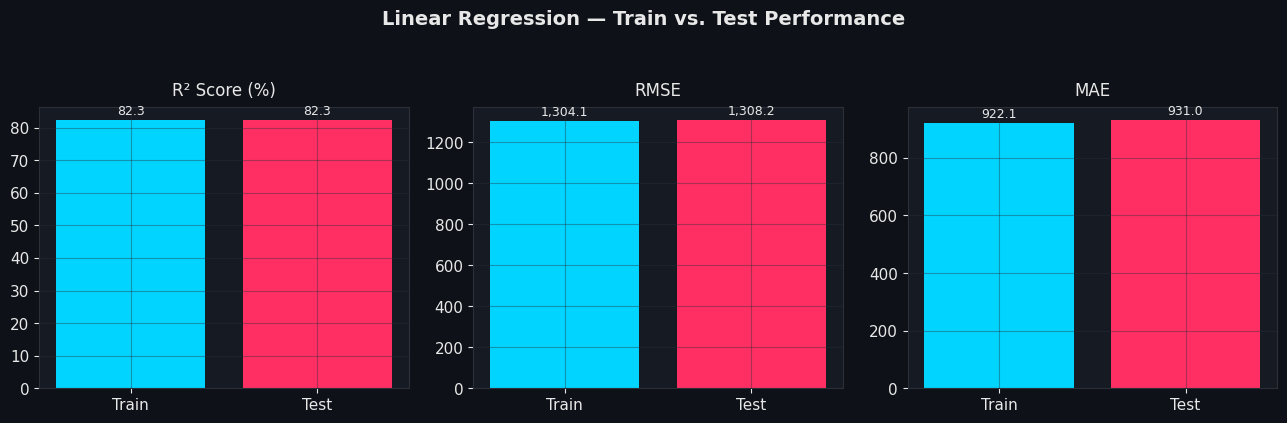

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_preds = lr_model.predict(X_test_scaled)
lr_train_preds = lr_model.predict(X_train_scaled)

results["Linear Regression"] = get_metrics(y_test, lr_preds)
train_results["Linear Regression"] = get_metrics(y_train, lr_train_preds)
predictions["Linear Regression"] = lr_preds
train_predictions["Linear Regression"] = lr_train_preds

plot_train_vs_test("Linear Regression", train_results["Linear Regression"], results["Linear Regression"])

## 8. Random Forest (tuned)

`max_depth` is capped at 12 and `min_samples_leaf`/`min_samples_split` are raised to control overfitting. The hyperparameter search runs on a subsample of the training set (every 5th row) to keep runtime reasonable; the final model is refit on the full training set.


Best RF params (found on subsample): {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_depth': 12}


Random Forest: Train R2=0.900 | Test R2=0.881 | Gap=0.019 -> train and test scores are close -> generalizing well.


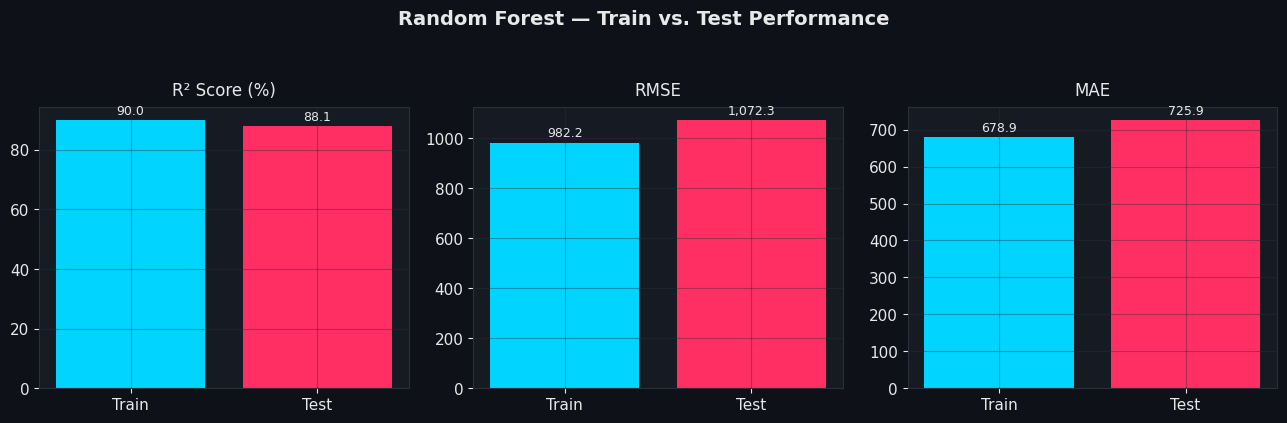

In [ ]:
sub_idx = np.arange(0, X_train_scaled.shape[0], 5)
X_sub, y_sub = X_train_scaled[sub_idx], y_train[sub_idx]

rf_param_dist = {
    "n_estimators": [100, 150, 200],
    "max_depth": [8, 10, 12],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [3, 5, 8],
    "max_features": ["sqrt", "log2"],
}
rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_dist, n_iter=5,
    cv=TimeSeriesSplit(n_splits=2), scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0,
)
rf_search.fit(X_sub, y_sub)
print("Best RF params (found on subsample):", rf_search.best_params_)

rf_model = RandomForestRegressor(**rf_search.best_params_, random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

rf_preds = rf_model.predict(X_test_scaled)
rf_train_preds = rf_model.predict(X_train_scaled)
results["Random Forest"] = get_metrics(y_test, rf_preds)
train_results["Random Forest"] = get_metrics(y_train, rf_train_preds)
predictions["Random Forest"] = rf_preds
train_predictions["Random Forest"] = rf_train_preds

plot_train_vs_test("Random Forest", train_results["Random Forest"], results["Random Forest"])

## 9. XGBoost (tuned)

Hyperparameters are searched over a wider grid (higher learning rates, more trees available) to give XGBoost a fair shot at matching Random Forest.


Best XGBoost params: {'subsample': 0.7, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 900, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 1.0}


XGBoost: Train R2=0.916 | Test R2=0.886 | Gap=0.030 -> train and test scores are close -> generalizing well.


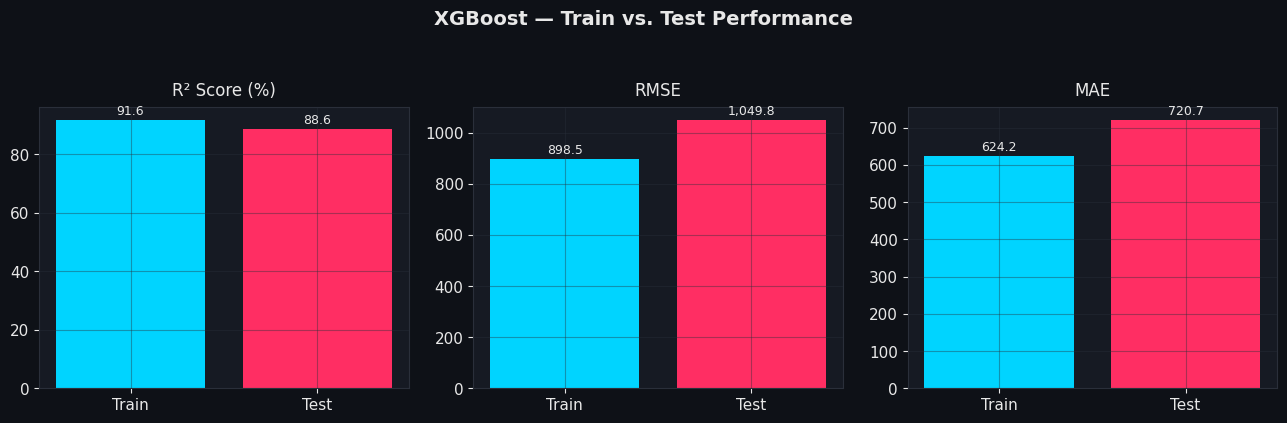

In [ ]:
xgb_param_dist = {
    "n_estimators": [300, 500, 700, 900],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.08, 0.1, 0.15],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 1.5, 2],
}
xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist"),
    param_distributions=xgb_param_dist, n_iter=10,
    cv=TimeSeriesSplit(n_splits=2), scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0,
)
xgb_search.fit(X_train_scaled, y_train)
xgb_model = xgb_search.best_estimator_
print("Best XGBoost params:", xgb_search.best_params_)

xgb_preds = xgb_model.predict(X_test_scaled)
xgb_train_preds = xgb_model.predict(X_train_scaled)
results["XGBoost"] = get_metrics(y_test, xgb_preds)
train_results["XGBoost"] = get_metrics(y_train, xgb_train_preds)
predictions["XGBoost"] = xgb_preds
train_predictions["XGBoost"] = xgb_train_preds

plot_train_vs_test("XGBoost", train_results["XGBoost"], results["XGBoost"])

## 11. Row-level model comparison

In [ ]:
comparison_df = pd.DataFrame(results).T[["MAE", "MSE", "RMSE", "R2", "MAPE"]]
comparison_df["R2"] = comparison_df["R2"] * 100
comparison_df = comparison_df.rename(columns={"R2": "R2 (Accuracy %)", "MAPE": "MAPE (%)"})
comparison_df = comparison_df.sort_values("R2 (Accuracy %)", ascending=False)

print(comparison_df.round(2).to_string())
print("\nTop of table by R2:", comparison_df.index[0])


best_model_name = "Random Forest"
print("Model selected for deployment (explicit choice):", best_model_name)

                      MAE         MSE     RMSE  R2 (Accuracy %)  MAPE (%)
XGBoost            720.68  1102021.25  1049.77            88.58     20.52
Random Forest      725.94  1149808.46  1072.29            88.09     20.63
Linear Regression  930.99  1711352.74  1308.19            82.27     22.99

Top of table by R2: XGBoost
Model selected for deployment (explicit choice): Random Forest


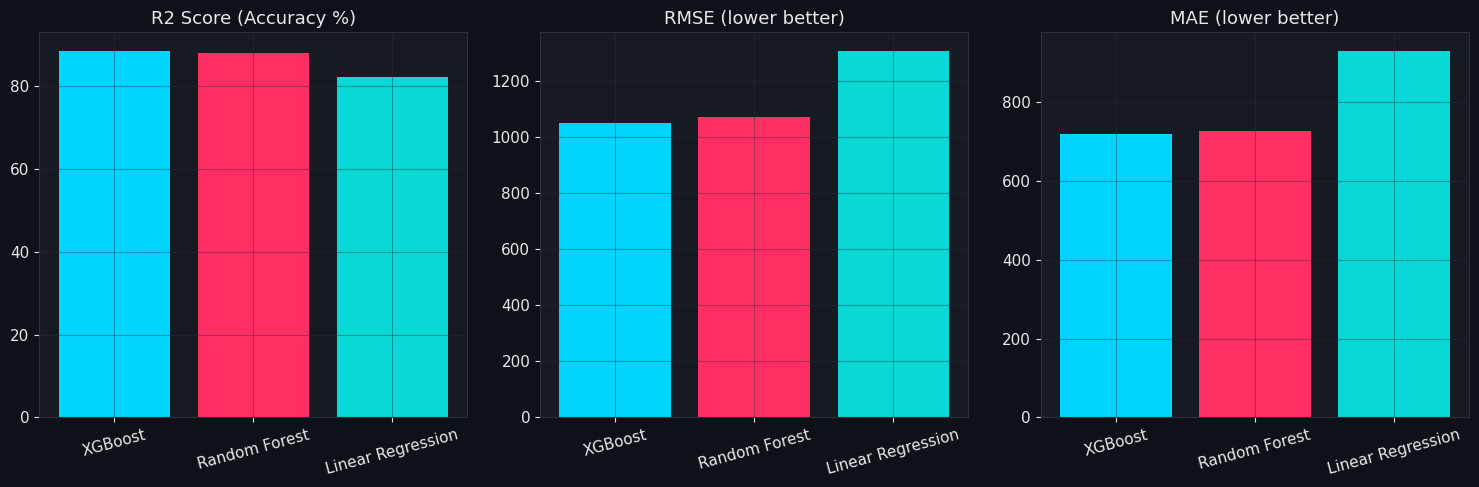

In [ ]:
model_names = list(comparison_df.index)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
metrics_to_plot = [("R2 (Accuracy %)", "R2 Score (Accuracy %)"), ("RMSE", "RMSE (lower better)"), ("MAE", "MAE (lower better)")]
for ax, (col, title) in zip(axes, metrics_to_plot):
    vals = comparison_df[col]
    ax.bar(model_names, vals, color=ACCENT[:len(model_names)])
    ax.set_title(title, fontsize=13)
    ax.tick_params(axis="x", rotation=20)
    style_spines(ax)
plt.tight_layout()
plt.show()

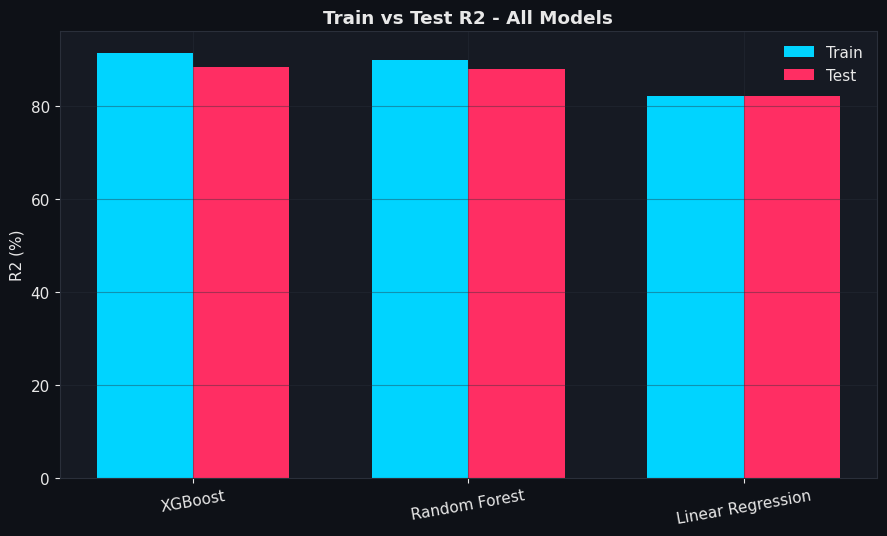

Train-Test R2 gap per model (smaller = healthier):
XGBoost              0.030
Random Forest        0.019
Linear Regression    0.001
dtype: float64


In [ ]:
train_r2 = [train_results[m]["R2"] * 100 for m in model_names]
test_r2 = [results[m]["R2"] * 100 for m in model_names]
x = np.arange(len(model_names)); width = 0.35
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(x - width/2, train_r2, width, label="Train", color=ACCENT[0])
ax.bar(x + width/2, test_r2, width, label="Test", color=ACCENT[1])
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=15)
ax.set_ylabel("R2 (%)"); ax.set_title("Train vs Test R2 - All Models", fontweight="bold")
ax.legend(frameon=False)
style_spines(ax)
plt.tight_layout()
plt.show()

gaps = pd.Series({m: train_results[m]["R2"] - results[m]["R2"] for m in model_names}).sort_values(ascending=False)
print("Train-Test R2 gap per model (smaller = healthier):")
print(gaps.round(3))

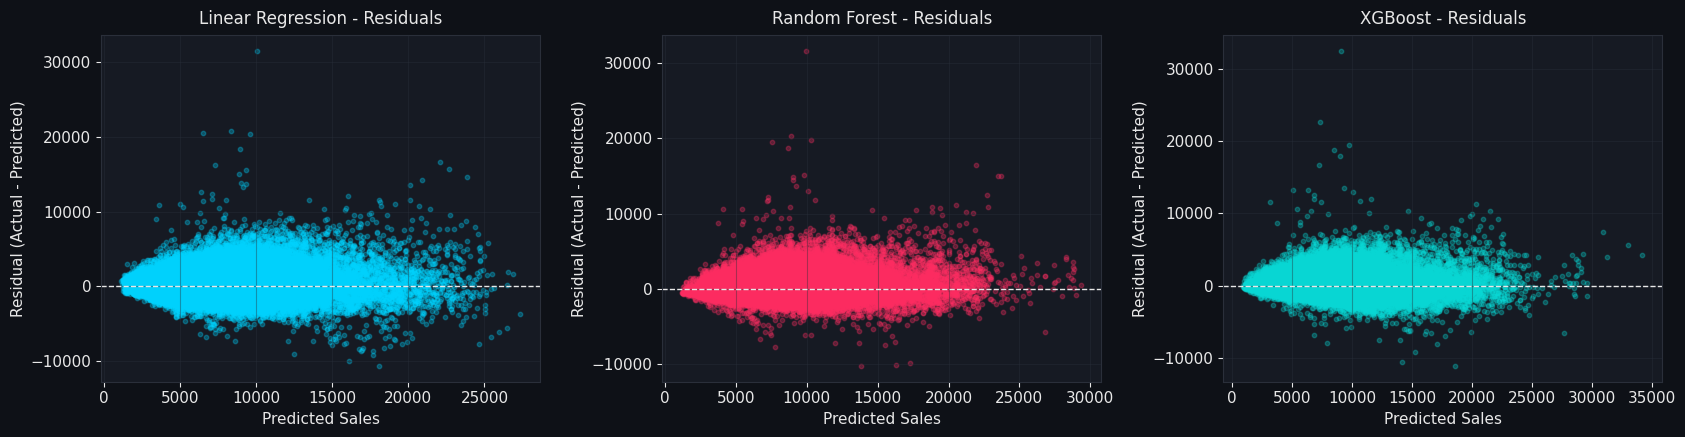

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, (name, color) in zip(axes, zip(results.keys(), ACCENT)):
    y_pred = predictions[name]
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.3, s=10, color=color)
    ax.axhline(0, color=TEXT_CLR, linestyle="--", linewidth=1)
    ax.set_title(f"{name} - Residuals", fontsize=12, pad=8)
    ax.set_xlabel("Predicted Sales"); ax.set_ylabel("Residual (Actual - Predicted)")
    style_spines(ax)
plt.tight_layout()
plt.show()

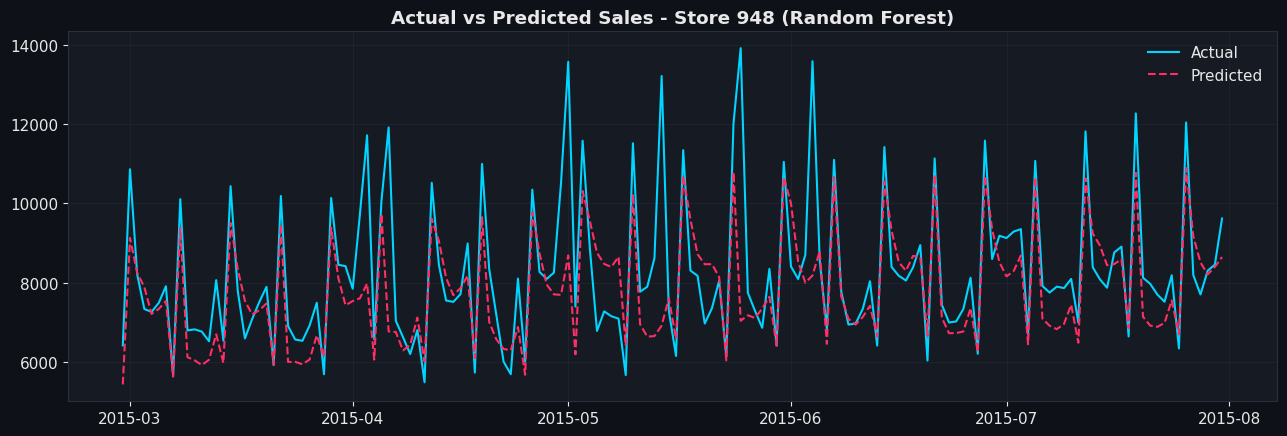

In [ ]:
sample_store = df.iloc[test_index]["Store"].value_counts().index[0]
mask = (df.iloc[test_index]["Store"] == sample_store).values
dates_sample = df.iloc[test_index]["Date"].values[mask]
actual_sample = y_test[mask]
pred_sample = predictions[best_model_name][mask]
order = np.argsort(dates_sample)

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(dates_sample[order], actual_sample[order], label="Actual", color=ACCENT[0], linewidth=1.5)
ax.plot(dates_sample[order], pred_sample[order], label="Predicted", color=ACCENT[1], linewidth=1.5, linestyle="--")
ax.set_title(f"Actual vs Predicted Sales - Store {sample_store} ({best_model_name})", fontweight="bold")
ax.legend(frameon=False)
style_spines(ax)
plt.tight_layout()
plt.show()

## 12. ARIMA on the daily aggregate (SARIMA)

Total daily sales drop to roughly 1/30th of a normal weekday every Sunday, since most stores close. A non-seasonal ARIMA can't represent that weekly cycle, so this uses a **seasonal ARIMA with a weekly seasonal term (s=7)**, grid-searched over AIC.


In [ ]:
daily_sales_full = df.groupby("Date")["Sales"].sum().asfreq("D").interpolate()
train_daily = daily_sales_full[daily_sales_full.index < cutoff_date]
test_daily = daily_sales_full[daily_sales_full.index >= cutoff_date]
print(f"Daily aggregate series -> train: {len(train_daily)} days, test: {len(test_daily)} days")

orders = [(p, 1, q) for p in [0, 1, 2] for q in [0, 1, 2]]
seasonal_orders = [(P, 1, Q, 7) for P in [0, 1] for Q in [0, 1]]

best_aic, best_order, best_sorder, best_arima_fit = np.inf, None, None, None
for order in orders:
    for sorder in seasonal_orders:
        try:
            fit = SARIMAX(train_daily, order=order, seasonal_order=sorder,
                           enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            if fit.aic < best_aic:
                best_aic, best_order, best_sorder, best_arima_fit = fit.aic, order, sorder, fit
        except Exception:
            continue

print(f"Best SARIMA order: {best_order} x {best_sorder}  (AIC={best_aic:.1f})")

arima_forecast = best_arima_fit.forecast(steps=len(test_daily))
arima_forecast.index = test_daily.index
ts_results = {"ARIMA": get_metrics(test_daily.values, arima_forecast.values)}
print("ARIMA:", {k: round(v, 3) for k, v in ts_results["ARIMA"].items()})

Daily aggregate series -> train: 788 days, test: 154 days


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best SARIMA order: (2, 1, 2) x (1, 1, 1, 7)  (AIC=24590.8)
ARIMA: {'MAE': 1318949.33, 'MSE': 4055278290669.729, 'RMSE': np.float64(2013772.155), 'R2': 0.632, 'MAPE': np.float64(107.71)}


## 13. Fair comparison: ARIMA vs. best ML model (both on the same daily-aggregate scale)

Row-level ML predictions are summed up to the daily level so the comparison with ARIMA is apples-to-apples.

                                 MAE           MSE        RMSE  R2 (Accuracy %)  MAPE (%)
Random Forest (aggregated)  426903.14  6.868398e+11   828757.97            93.76      6.23
ARIMA                      1318949.33  4.055278e+12  2013772.15            63.16    107.71


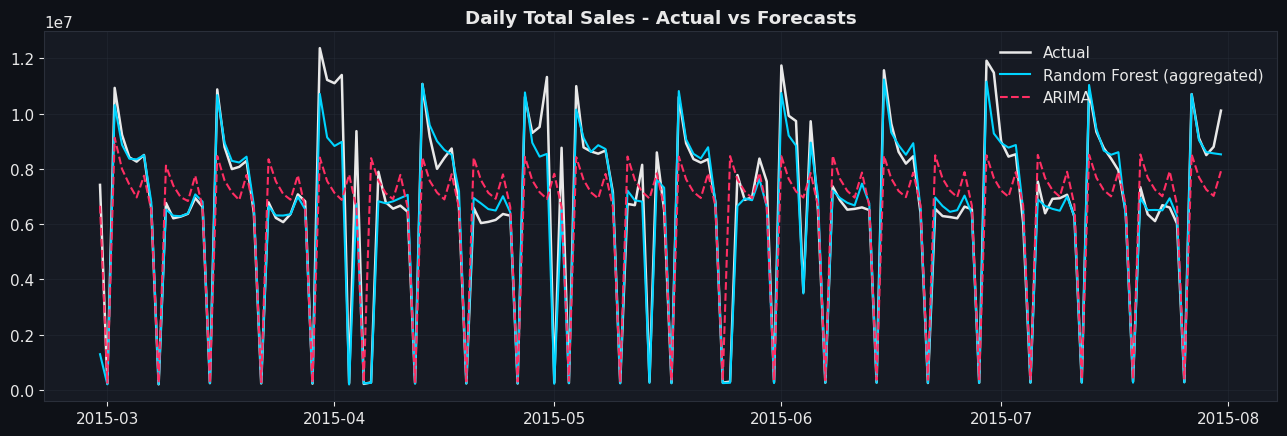

In [ ]:
ml_daily_pred = (
    df.iloc[test_index][["Date"]]
    .assign(Predicted=predictions[best_model_name])
    .groupby("Date")["Predicted"].sum()
    .reindex(test_daily.index)
)
ts_results[f"{best_model_name} (aggregated)"] = get_metrics(test_daily.values, ml_daily_pred.values)

ts_comparison_df = pd.DataFrame(ts_results).T[["MAE", "MSE", "RMSE", "R2", "MAPE"]]
ts_comparison_df["R2"] = ts_comparison_df["R2"] * 100
ts_comparison_df = ts_comparison_df.rename(columns={"R2": "R2 (Accuracy %)", "MAPE": "MAPE (%)"})
ts_comparison_df = ts_comparison_df.sort_values("R2 (Accuracy %)", ascending=False)
print(ts_comparison_df.round(2).to_string())

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(test_daily.index, test_daily.values, label="Actual", color=TEXT_CLR, linewidth=1.8)
ax.plot(test_daily.index, ml_daily_pred.values, label=f"{best_model_name} (aggregated)", color=ACCENT[0], linewidth=1.5)
ax.plot(test_daily.index, arima_forecast.values, label="ARIMA", color=ACCENT[1], linewidth=1.5, linestyle="--")
ax.set_title("Daily Total Sales - Actual vs Forecasts", fontweight="bold")
ax.legend(frameon=False)
style_spines(ax)
plt.tight_layout()
plt.show()

## 14. Feature importance (Random Forest vs. XGBoost)

Top 8 RF features:
 Sales_Lag_14            0.2190
Store_Month_AvgSales    0.1930
Sales_RollingMean_30    0.1491
Sales_RollingMean_7     0.1280
Promo                   0.1021
Sales_Lag_7             0.0693
Sales_Lag_30            0.0383
Sales_RollingStd_7      0.0231
dtype: float64

Top 8 XGB features:
 Sales_Lag_14            0.3842
Store_Month_AvgSales    0.2384
Promo                   0.1197
DOW_cos                 0.0400
IsWeekend               0.0338
Sales_RollingMean_7     0.0326
DOW_sin                 0.0206
Sales_Lag_7             0.0119
dtype: float32


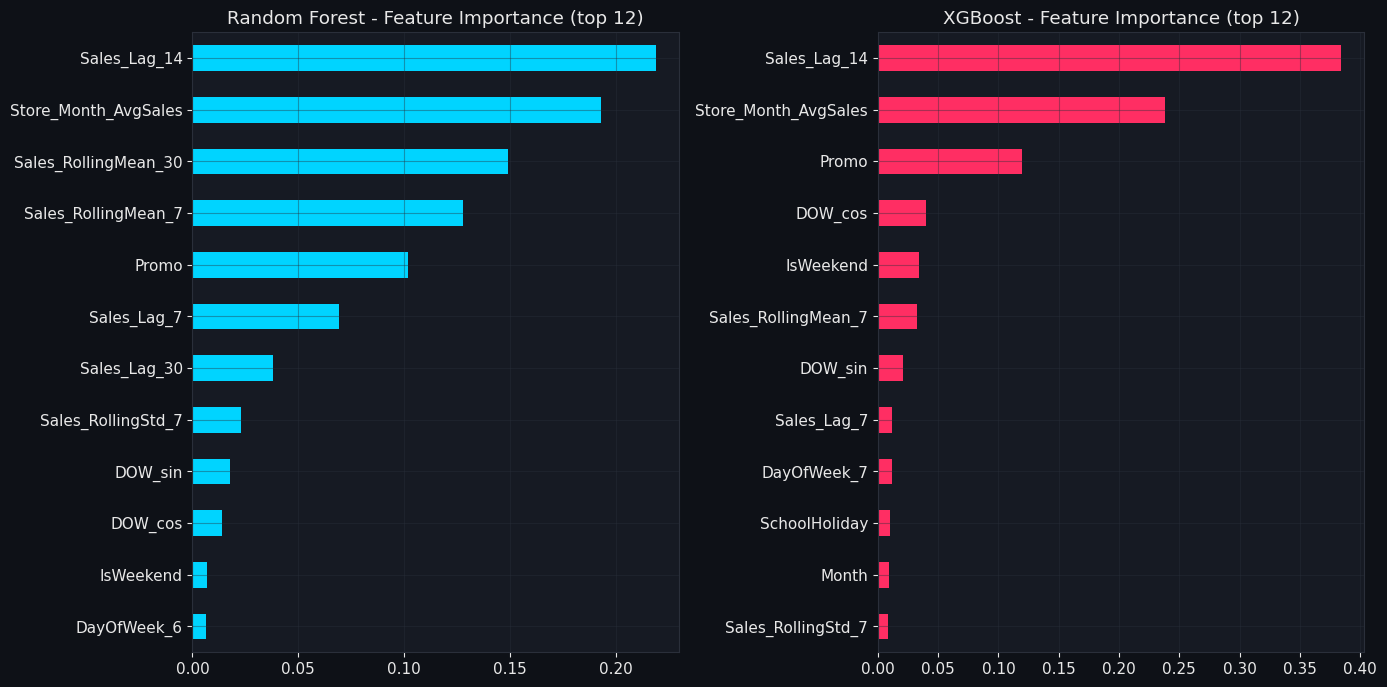

In [ ]:
rf_imp = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
xgb_imp = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
rf_imp.head(12)[::-1].plot(kind="barh", ax=axes[0], color=ACCENT[0])
axes[0].set_title("Random Forest - Feature Importance (top 12)")
xgb_imp.head(12)[::-1].plot(kind="barh", ax=axes[1], color=ACCENT[1])
axes[1].set_title("XGBoost - Feature Importance (top 12)")
for ax in axes:
    style_spines(ax)
plt.tight_layout()
plt.show()

print("Top 8 RF features:\n", rf_imp.head(8).round(4))
print("\nTop 8 XGB features:\n", xgb_imp.head(8).round(4))

## 15. Permutation importance (model-agnostic)

Computed for **XGBoost and Random Forest** — this metric only needs a model's `.predict` method.

Top 8 permutation importance features:
 Store_Month_AvgSales    0.4262
Promo                   0.3924
Sales_Lag_14            0.1118
Sales_RollingMean_7     0.0929
Sales_Lag_7             0.0490
DOW_cos                 0.0425
Sales_RollingMean_30    0.0271
Sales_RollingStd_7      0.0183
dtype: float64


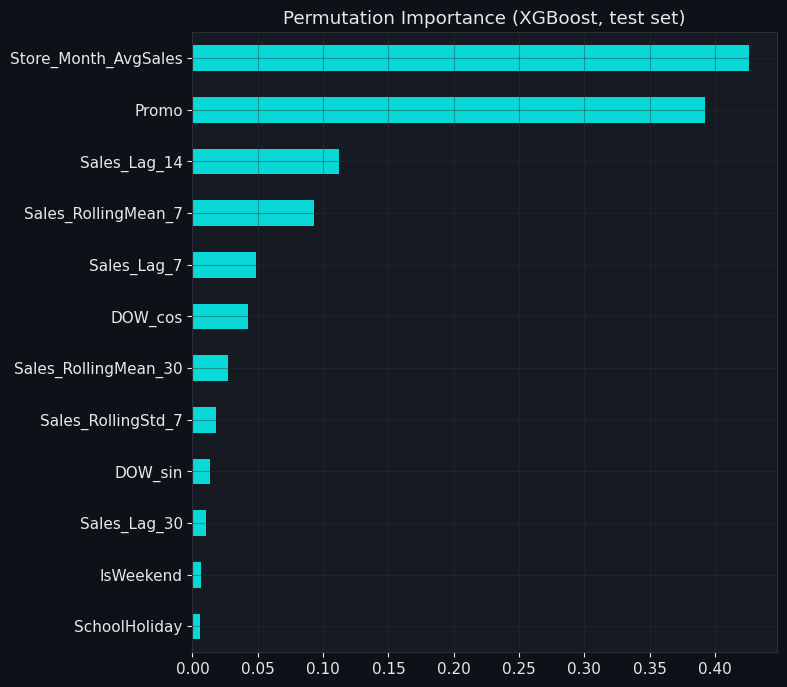

In [ ]:
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(y_test), size=min(30000, len(y_test)), replace=False)
perm = permutation_importance(xgb_model, X_test_scaled[sample_idx], y_test[sample_idx],
                               n_repeats=3, random_state=RANDOM_STATE, n_jobs=1)
perm_imp = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
perm_imp.head(12)[::-1].plot(kind="barh", ax=ax, color=ACCENT[2])
ax.set_title("Permutation Importance (XGBoost, test set)")
style_spines(ax)
plt.tight_layout()
plt.show()

print("Top 8 permutation importance features:\n", perm_imp.head(8).round(4))

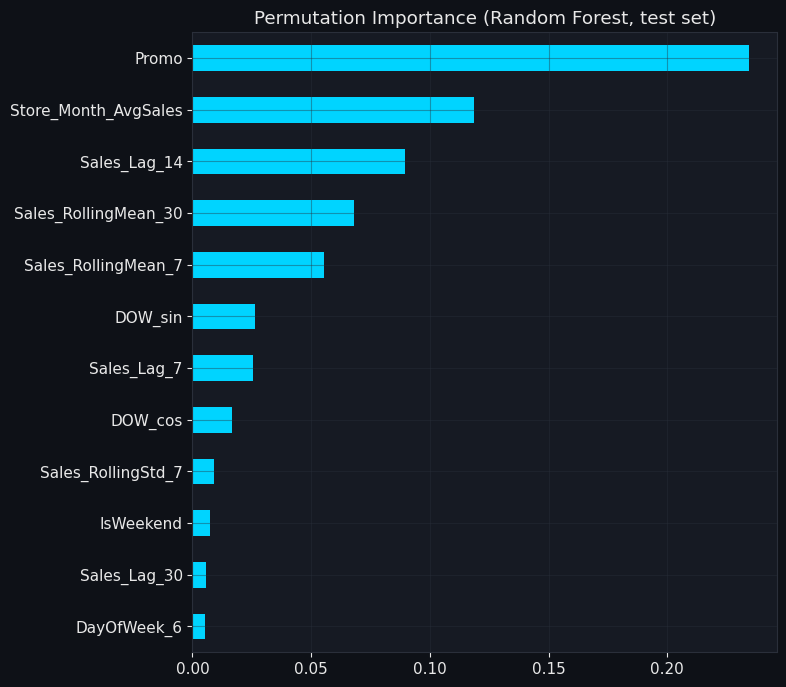

Top 8 permutation importance features - Random Forest:
 Promo                   0.2345
Store_Month_AvgSales    0.1186
Sales_Lag_14            0.0897
Sales_RollingMean_30    0.0680
Sales_RollingMean_7     0.0553
DOW_sin                 0.0264
Sales_Lag_7             0.0255
DOW_cos                 0.0164
dtype: float64


In [ ]:
perm_rf = permutation_importance(rf_model, X_test_scaled[sample_idx], y_test[sample_idx],
                                  n_repeats=3, random_state=RANDOM_STATE, n_jobs=1)
perm_imp_rf = pd.Series(perm_rf.importances_mean, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
perm_imp_rf.head(12)[::-1].plot(kind="barh", ax=ax, color=ACCENT[0])
ax.set_title("Permutation Importance (Random Forest, test set)")
style_spines(ax)
plt.tight_layout()
plt.show()

print("Top 8 permutation importance features - Random Forest:\n", perm_imp_rf.head(8).round(4))

## 16. SHAP explainability — XGBoost & Random Forest

`TreeExplainer` natively supports both Random Forest and XGBoost (both are tree ensembles), so SHAP is computed directly for each.

In [ ]:
import shap

sample_idx_shap = rng.choice(X_test_scaled.shape[0], size=1500, replace=False)
X_sample = pd.DataFrame(X_test_scaled[sample_idx_shap], columns=feature_cols)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_sample)
print("SHAP values computed on a sample of", X_sample.shape[0], "test rows.")

SHAP values computed on a sample of 1500 test rows.


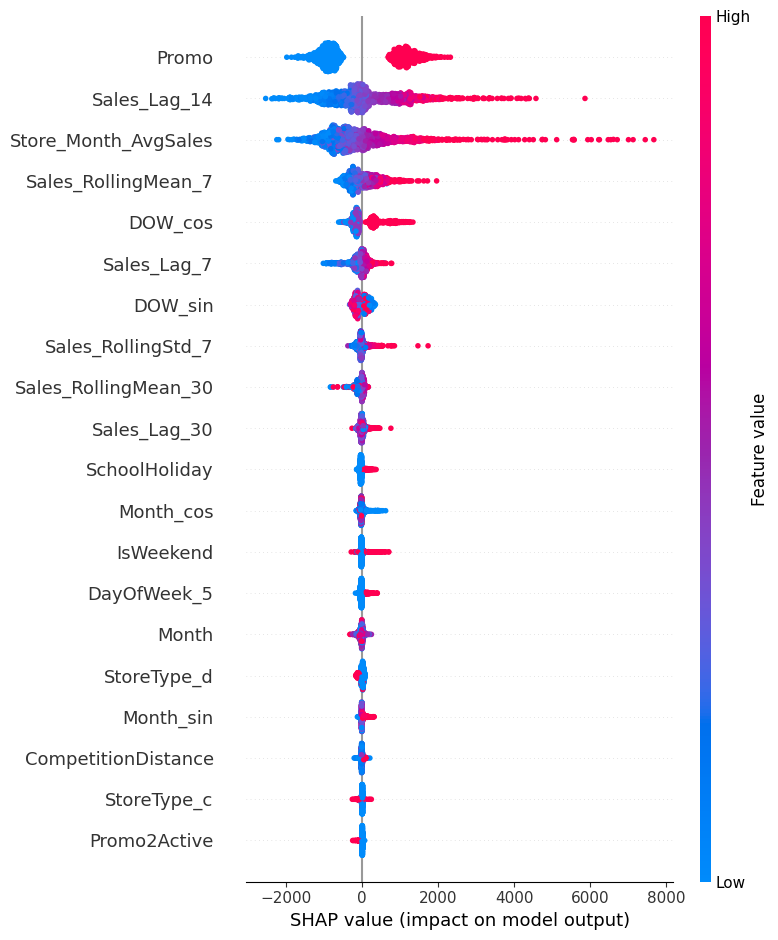

In [ ]:
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
darkify_fig()
plt.show()

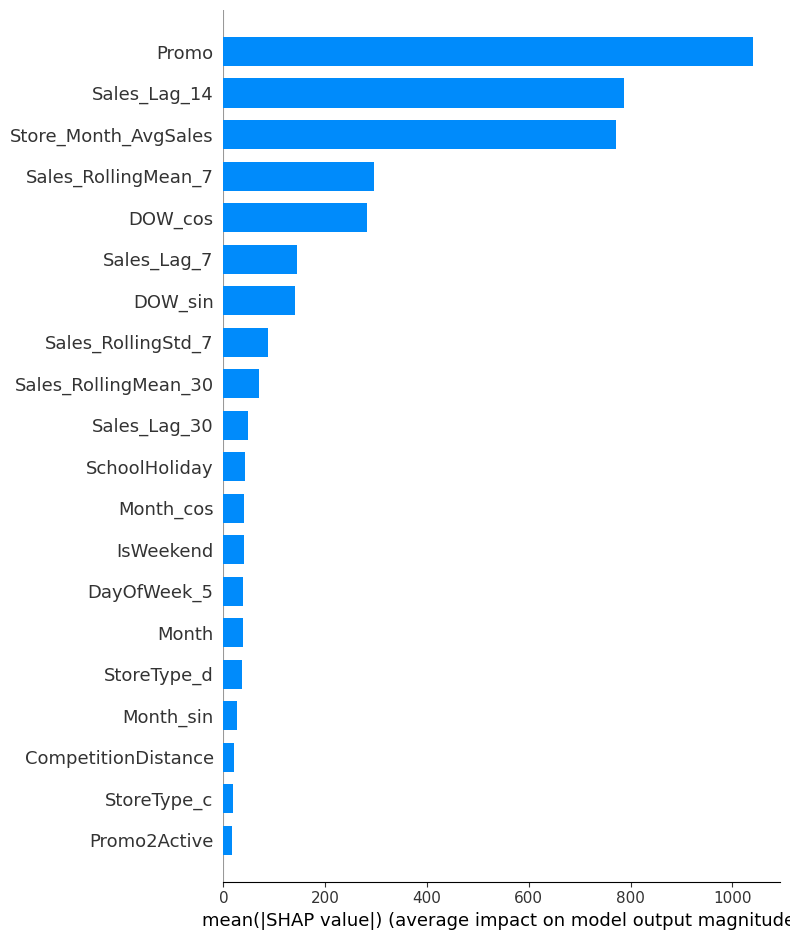

In [ ]:
plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.tight_layout()
darkify_fig()
plt.show()

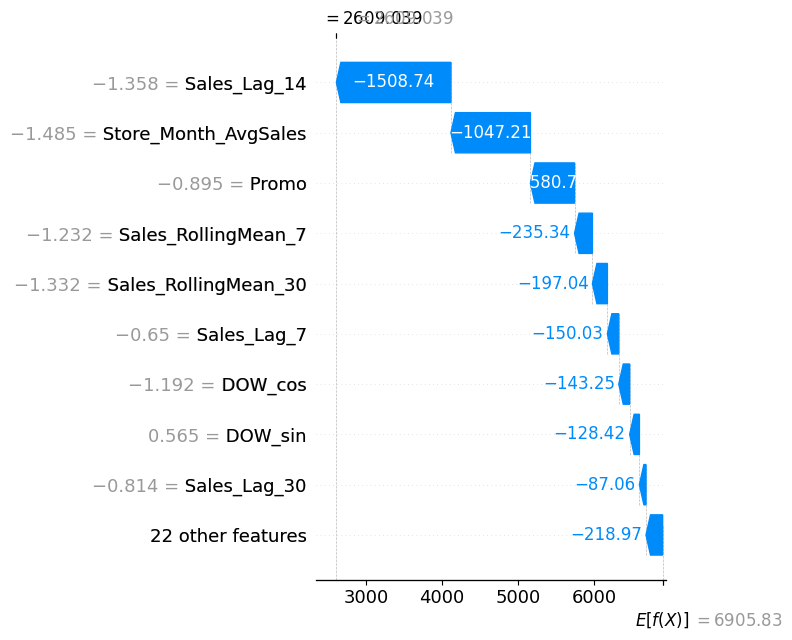

In [ ]:
plt.figure()
shap.plots.waterfall(shap_values[0], show=False)
plt.tight_layout()
darkify_fig()
plt.show()

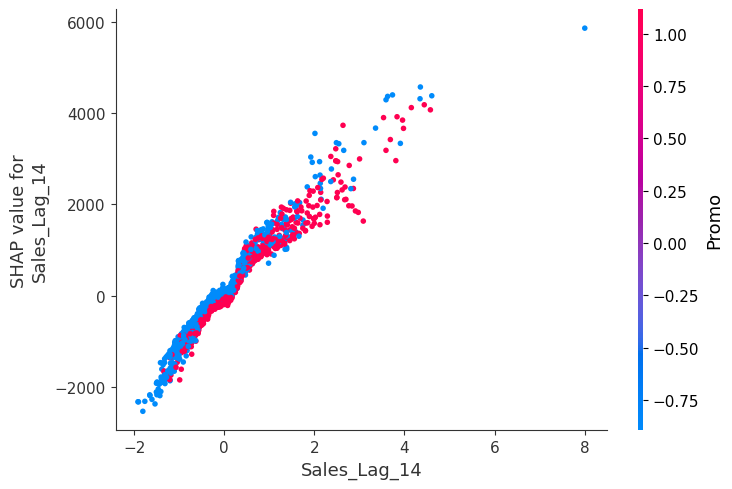

In [ ]:
top_feat = "Sales_Lag_14" if "Sales_Lag_14" in feature_cols else feature_cols[0]
plt.figure()
shap.dependence_plot(top_feat, shap_values.values, X_sample, show=False)
plt.tight_layout()
darkify_fig()
plt.show()

SHAP (Random Forest) computed on 1500 rows


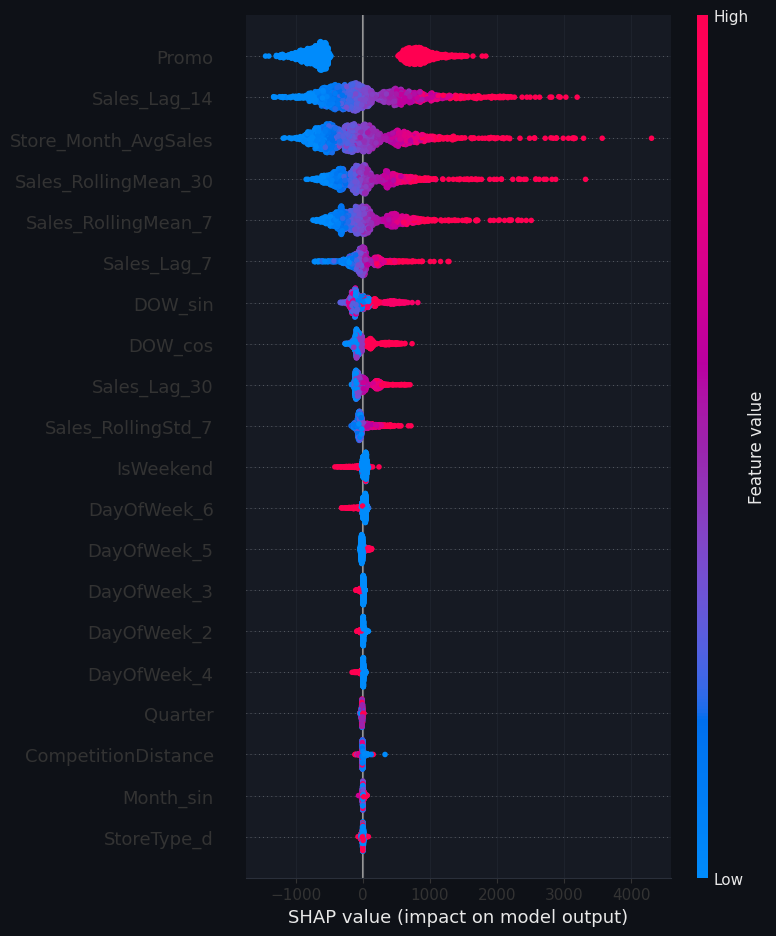

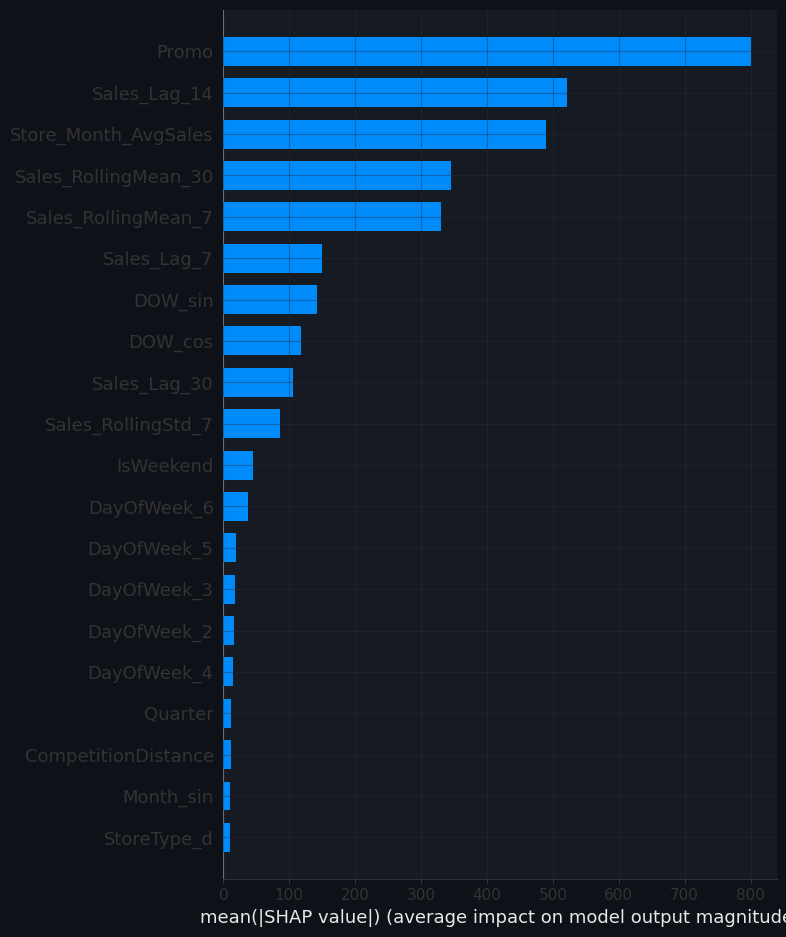

In [ ]:
explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf(X_sample)
print("SHAP (Random Forest) computed on", X_sample.shape[0], "rows")

plt.figure()
shap.summary_plot(shap_values_rf, X_sample, show=False)
plt.tight_layout()
darkify_fig()
plt.show()

plt.figure()
shap.summary_plot(shap_values_rf, X_sample, plot_type="bar", show=False)
plt.tight_layout()
darkify_fig()
plt.show()

## 17. Save the final model for deployment

In [ ]:
print(comparison_df.round(2).to_string())
print("\nSelected for deployment (explicit project choice):", best_model_name)

payload = dict(model_type="Random Forest", model=rf_model, scaler=scaler, feature_cols=feature_cols)
joblib.dump(payload, "rossmann_sales_model.pkl")
print("Saved -> rossmann_sales_model.pkl")

                      MAE         MSE     RMSE  R2 (Accuracy %)  MAPE (%)
XGBoost            720.68  1102021.25  1049.77            88.58     20.52
Random Forest      725.94  1149808.46  1072.29            88.09     20.63
Linear Regression  930.99  1711352.74  1308.19            82.27     22.99

Selected for deployment (explicit project choice): Random Forest
Saved -> rossmann_sales_model.pkl
